[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1mGfwiN4bkWtV_LrwEpv28Avp0tie-byO?usp=sharing)

## Loading dataset

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pylab as plt
import random

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


## An overview of the images

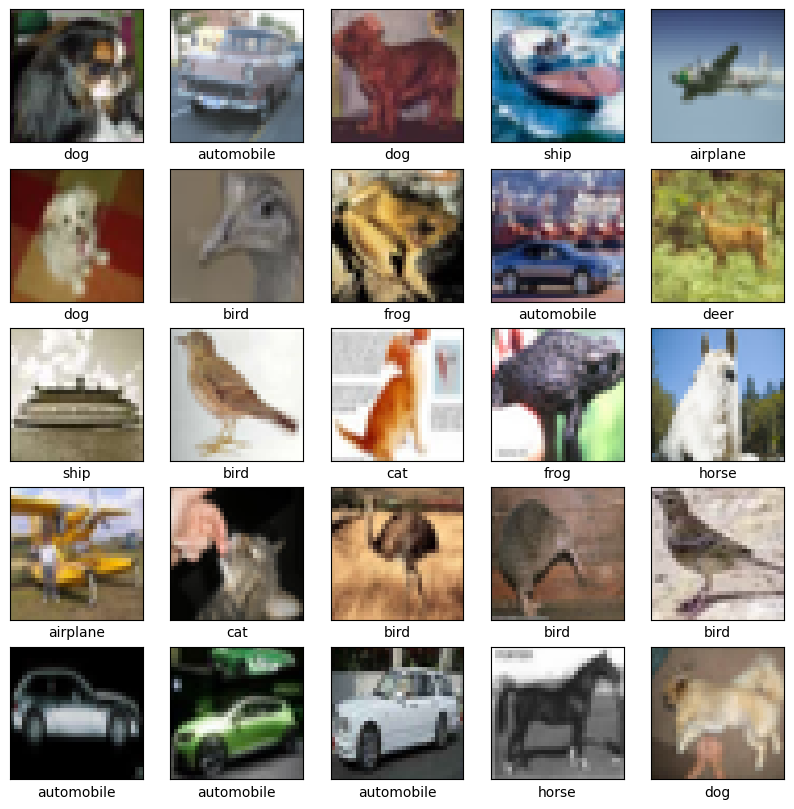

In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

train_idx = list(range(len(train_labels)))

random.seed(1)
random_sample = random.sample(train_idx, 25)

plt.figure(figsize=(10,10))
for i in range(len(random_sample)):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[random_sample[i]], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[random_sample[i]][0]])
plt.show()

## Color channels

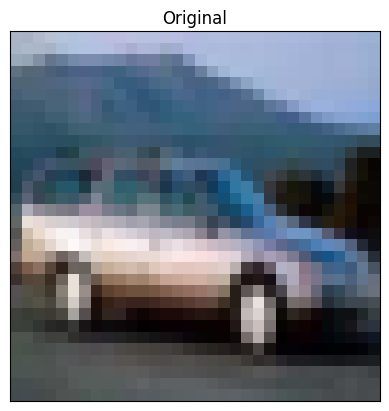

In [3]:
image_id = 4
plt.figure()
plt.imshow(train_images[image_id], cmap=plt.cm.binary)
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.title('Original')
plt.show()

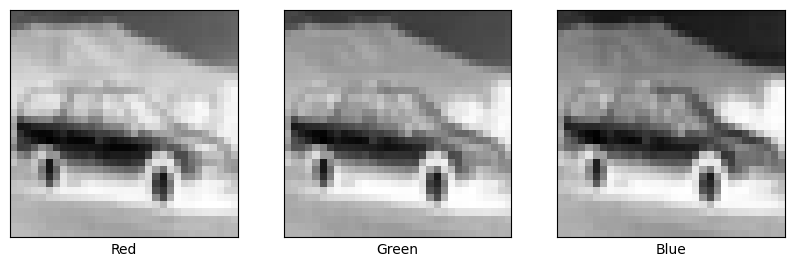

In [5]:
channel = ['Red', 'Green', 'Blue']
plt.figure(figsize=(10,10))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[image_id][:,:, i], cmap=plt.cm.binary)
    plt.xlabel(channel[i])
plt.show()


##Build, compile and train the model

## Challenge 1

In [4]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((test_images[:5000], test_labels[:5000]))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images[5000:], test_labels[5000:]))

TRAIN_DATASET_SIZE = len(train_dataset)
VALIDATION_DATASET_SIZE = len(validation_dataset)
TEST_DATASET_SIZE = len(test_dataset)

BATCH_SIZE = 128

train_dataset = train_dataset.shuffle(TRAIN_DATASET_SIZE).batch(BATCH_SIZE)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

VALIDATION_STEPS = VALIDATION_DATASET_SIZE // BATCH_SIZE

Make changes only in the cell below

In [9]:
#build
model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
  tf.keras.layers.Dense(1024, activation='relu'),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(10),
  ])
#compile
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
#train
model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    validation_steps=VALIDATION_STEPS)

_, accuracy = model.evaluate(test_dataset)
print(f'The model accuracy is {accuracy * 100:0.1f}%')

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3069 - loss: 1.9176 - val_accuracy: 0.3774 - val_loss: 1.7625
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3873 - loss: 1.7222 - val_accuracy: 0.4165 - val_loss: 1.6472
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4107 - loss: 1.6529 - val_accuracy: 0.4191 - val_loss: 1.6283
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4305 - loss: 1.6006 - val_accuracy: 0.4395 - val_loss: 1.5661
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4429 - loss: 1.5600 - val_accuracy: 0.4583 - val_loss: 1.5327
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4538 - loss: 1.5379 - val_accuracy: 0.4651 - val_loss: 1.5228
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4601 - loss: 1.5194 - val_accuracy: 0.4585 - val_loss: 1.5372
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4668 - loss: 1.4944 - val_accuracy: 0.

## Challenge 2

Make changes only to the cell below

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((test_images[:5000], test_labels[:5000]))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images[5000:], test_labels[5000:]))

TRAIN_DATASET_SIZE = len(train_dataset)
VALIDATION_DATASET_SIZE = len(validation_dataset)
TEST_DATASET_SIZE = len(test_dataset)

BATCH_SIZE = 128

train_dataset = train_dataset.shuffle(TRAIN_DATASET_SIZE).batch(BATCH_SIZE)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

VALIDATION_STEPS = VALIDATION_DATASET_SIZE // BATCH_SIZE

#build
model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(10),
  ])
#compile
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
#train
model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    validation_steps=VALIDATION_STEPS)

_, accuracy = model.evaluate(test_dataset)
print(f'The model accuracy is {accuracy * 100:0.1f}%')

Epoch 1/10
391/391 [==============================] - 3s 6ms/step - loss: 1.9002 - accuracy: 0.3181 - val_loss: 1.7840 - val_accuracy: 0.3648
Epoch 2/10
391/391 [==============================] - 2s 6ms/step - loss: 1.7184 - accuracy: 0.3856 - val_loss: 1.6399 - val_accuracy: 0.4087
Epoch 3/10
391/391 [==============================] - 2s 6ms/step - loss: 1.6419 - accuracy: 0.4139 - val_loss: 1.6072 - val_accuracy: 0.4259
Epoch 4/10
391/391 [==============================] - 2s 6ms/step - loss: 1.5917 - accuracy: 0.4317 - val_loss: 1.5635 - val_accuracy: 0.4449
Epoch 5/10
391/391 [==============================] - 2s 6ms/step - loss: 1.5591 - accuracy: 0.4468 - val_loss: 1.5257 - val_accuracy: 0.4579
Epoch 6/10
391/391 [==============================] - 3s 6ms/step - loss: 1.5306 - accuracy: 0.4545 - val_loss: 1.5334 - val_accuracy: 0.4591
Epoch 7/10
391/391 [==============================] - 2s 6ms/step - loss: 1.5097 - accuracy: 0.4624 - val_loss: 1.5339 - val_accuracy: 0.4573
Epoch 